In [3]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from src.data_loader import get_con

con = get_con()
print("Connected to DuckDB")

Connected to DuckDB


In [4]:
# Snapshot date = one day after last order in dataset
snapshot = "2018-09-30"

rfm_raw = con.execute(f"""
    SELECT
        c.customer_unique_id,
        DATEDIFF('day', MAX(o.order_purchase_timestamp::DATE), 
                        '{snapshot}'::DATE)          AS recency,
        COUNT(DISTINCT o.order_id)                   AS frequency,
        SUM(p.payment_value)                         AS monetary
    FROM orders o
    JOIN customers c USING (customer_id)
    JOIN payments p USING (order_id)
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
""").df()

print(f"Customers: {len(rfm_raw):,}")
print(rfm_raw.describe().round(2))

Customers: 93,357
        recency  frequency  monetary
count  93357.00   93357.00  93357.00
mean     269.47       1.03    165.20
std      152.59       0.21    226.31
min       32.00       1.00      9.59
25%      146.00       1.00     63.06
50%      250.00       1.00    107.78
75%      378.00       1.00    182.56
max      727.00      15.00  13664.08


In [5]:
rfm = rfm_raw.copy()

# Score 1-5 for each dimension
# Recency: lower days = better = score 5
rfm["R"] = pd.qcut(rfm["recency"],   q=5, labels=[5,4,3,2,1]).astype(int)
# Frequency: higher = better = score 5
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 
                   q=5, labels=[1,2,3,4,5]).astype(int)
# Monetary: higher = better = score 5
rfm["M"] = pd.qcut(rfm["monetary"],  q=5, labels=[1,2,3,4,5]).astype(int)

rfm["RFM_score"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)
rfm["RFM_total"] = rfm["R"] + rfm["F"] + rfm["M"]

# Segment assignment
def assign_segment(r, f):
    if   r >= 4 and f >= 4: return "Champions"
    elif r >= 3 and f >= 3: return "Loyal Customers"
    elif r >= 4 and f <= 2: return "New Customers"
    elif r >= 3 and f <= 2: return "Potential Loyalists"
    elif r == 2 and f >= 3: return "At Risk"
    elif r <= 2 and f >= 4: return "Cannot Lose Them"
    elif r <= 2 and f <= 2: return "Hibernating"
    else:                   return "Lost"

rfm["segment"] = rfm.apply(lambda x: assign_segment(x["R"], x["F"]), axis=1)

print(rfm["segment"].value_counts())

segment
Loyal Customers        18693
Champions              15141
Hibernating            14895
New Customers          14866
At Risk                11105
Potential Loyalists     7582
Cannot Lose Them        7371
Lost                    3704
Name: count, dtype: int64


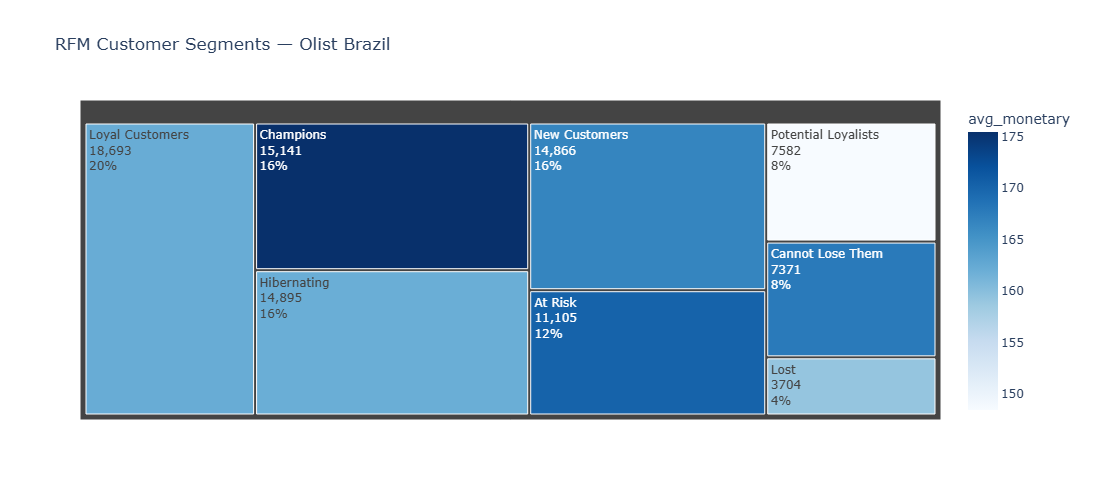

In [6]:
seg_summary = rfm.groupby("segment").agg(
    customers  = ("customer_unique_id", "count"),
    avg_monetary = ("monetary", "mean"),
    avg_recency  = ("recency",  "mean")
).reset_index().round(2)

fig1 = px.treemap(
    seg_summary,
    path=["segment"],
    values="customers",
    color="avg_monetary",
    color_continuous_scale="Blues",
    title="RFM Customer Segments — Olist Brazil",
    hover_data={"avg_recency": True, "avg_monetary": True}
)
fig1.update_traces(textinfo="label+value+percent root")
fig1.update_layout(height=500)
fig1.show()

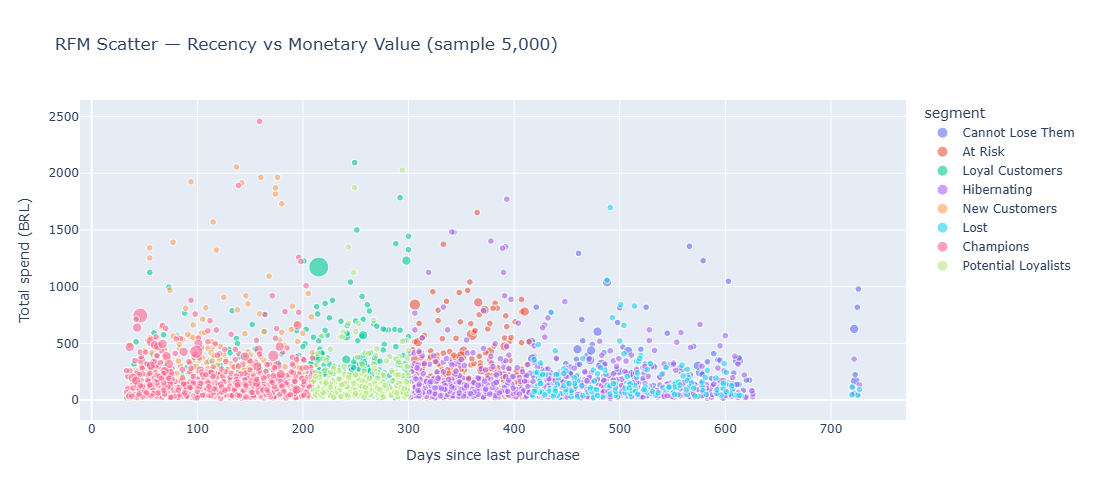

In [7]:
fig2 = px.scatter(
    rfm.sample(5000, random_state=42),
    x="recency",
    y="monetary",
    color="segment",
    size="frequency",
    opacity=0.6,
    title="RFM Scatter — Recency vs Monetary Value (sample 5,000)",
    labels={"recency": "Days since last purchase",
            "monetary": "Total spend (BRL)"}
)
fig2.update_layout(height=500)
fig2.show()

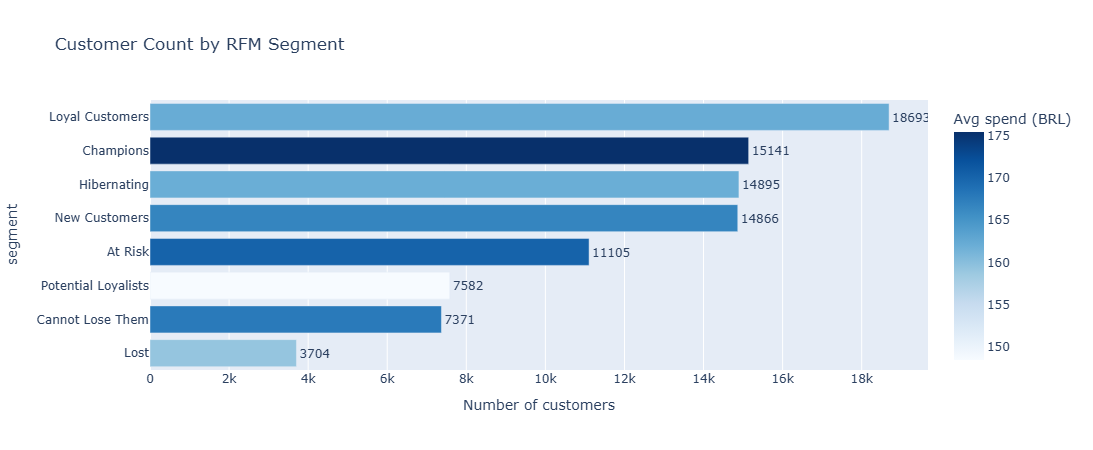

In [8]:
seg_order = seg_summary.sort_values("customers", ascending=True)

fig3 = px.bar(
    seg_order,
    x="customers",
    y="segment",
    orientation="h",
    color="avg_monetary",
    color_continuous_scale="Blues",
    text="customers",
    title="Customer Count by RFM Segment",
    labels={"customers": "Number of customers",
            "avg_monetary": "Avg spend (BRL)"}
)
fig3.update_traces(textposition="outside")
fig3.update_layout(height=450)
fig3.show()

In [9]:
import os
os.makedirs("../docs/screenshots", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

fig1.write_html("../docs/screenshots/02_rfm_treemap.html")
fig2.write_html("../docs/screenshots/02_rfm_scatter.html")
fig3.write_html("../docs/screenshots/02_rfm_segments.html")

rfm.to_csv("../data/processed/02_rfm_scores.csv", index=False)
seg_summary.to_csv("../data/processed/02_rfm_summary.csv", index=False)

print("Saved all outputs")

Saved all outputs


In [10]:
print("RFM SEGMENTATION SUMMARY")
print(f"Total customers scored : {len(rfm):,}")
print(f"Snapshot date          : {snapshot}")
print()
print(seg_summary.sort_values("customers", ascending=False)
      [["segment","customers","avg_monetary","avg_recency"]]
      .to_string(index=False))
print()
print("FINDINGS:")
print("1. Loyal Customers is the largest segment (18,693)")
print("2. Champions + Loyal = 33,834 (36%) — core revenue base")
print("3. Hibernating + Lost = 18,599 (20%) — at risk of permanent churn")
print("4. Avg monetary value highest in Cannot Lose Them segment")

RFM SEGMENTATION SUMMARY
Total customers scored : 93,357
Snapshot date          : 2018-09-30

            segment  customers  avg_monetary  avg_recency
    Loyal Customers      18693        162.19       200.09
          Champions      15141        175.49       122.53
        Hibernating      14895        162.02       428.08
      New Customers      14866        166.71       122.08
            At Risk      11105        170.20       348.31
Potential Loyalists       7582        148.45       252.66
   Cannot Lose Them       7371        167.76       504.15
               Lost       3704        159.20       505.18

FINDINGS:
1. Loyal Customers is the largest segment (18,693)
2. Champions + Loyal = 33,834 (36%) — core revenue base
3. Hibernating + Lost = 18,599 (20%) — at risk of permanent churn
4. Avg monetary value highest in Cannot Lose Them segment


In [11]:
con.close()
print("Connection closed")

Connection closed
